# Brain Stroke Risk Analysis: A Comparative Study Using Frequentist and Bayesian Logistic Regression

**Author:** Wonjae Lee  
**Affiliation:** University of California, Irvine  
**Date:** March 2026  
**Statistical Methods:** Linear Probability Model, Frequentist Logistic Regression, Bayesian Logistic Regression, Lasso Regularization

### Abstract

This project analyzes the Brain Stroke Dataset, a patient-level dataset containing demographic, lifestyle, and medical variables associated with stroke risk. The response variable is stroke, a binary indicator of whether an individual has experienced a stroke. The main objective of this study is both explanatory and predictive: to identify the factors most strongly associated with stroke occurrence and to compare the performance of several regression-based models for predicting stroke risk.

Because the outcome variable is binary, the analysis focuses primarily on a frequentist logistic regression model and a Bayesian logistic regression model, while a linear probability model is included as a simple baseline for comparison. Exploratory data analysis is used to examine the distribution of predictors and their relationship with stroke, and special attention is given to the class imbalance in the dataset, since stroke cases are relatively rare. Model evaluation is based on metrics more appropriate for imbalanced classification problems, including ROC-AUC, precision, recall, and F1 score.

The results show that several health-related and demographic variables, particularly age and cardiovascular risk factors such as hypertension and heart disease, are important predictors of stroke. Among the models considered, logistic-regression-based approaches provide a better balance of interpretability and statistical validity than the linear probability model. Overall, this project finds that logistic regression is the most appropriate framework for modeling stroke occurrence in this dataset, while the Bayesian approach provides additional uncertainty quantification that complements the frequentist analysis.

### Introduction

Stroke is a major health concern because it can lead to death, long-term disability, and substantial reductions in quality of life. As a result, identifying factors associated with stroke risk is an important problem in both medicine and public health. Statistical modeling can help improve understanding of stroke-related risk factors and provide tools for estimating the probability of stroke occurrence based on patient characteristics.

This project analyzes the Brain Stroke Dataset, which contains patient-level demographic, lifestyle, and medical variables related to stroke risk. The dataset includes predictors such as age, hypertension, heart disease, glucose level, BMI, smoking status, and other background characteristics, with stroke as the binary response variable indicating whether a patient has experienced a stroke. Also, there was no missing values in the data.

The purpose of this analysis is both explanatory and predictive: to identify which factors are most strongly associated with stroke and to compare the performance of several regression-based models for predicting stroke occurrence. Since the outcome is binary, the main focus is on frequentist logistic regression and Bayesian logistic regression, while a linear probability model is included as a simple baseline for comparison.

Because stroke cases are relatively rare in the data, this project also pays careful attention to class imbalance and uses evaluation metrics beyond simple accuracy, including ROC-AUC, precision, recall, and F1 score. Through exploratory data analysis, model fitting, and model comparison, the final goal is to determine which method provides the best balance of interpretability, statistical validity, and predictive performance for this dataset.

### Literature Review

Stroke is a major public-health concern because it is both a leading cause of death and a major cause of long-term disability. In the United States, the CDC describes stroke as a leading cause of death and a major cause of serious disability in adults, while the WHO identifies stroke as an ongoing global health challenge requiring stronger prevention, treatment, and rehabilitation systems.

Prior literature has identified both non-modifiable and modifiable stroke risk factors. Boehme, Esenwa, and Elkind classify age, sex, race/ethnicity, and genetics as non-modifiable factors, and they note that stroke is strongly associated with aging, with incidence increasing substantially at older ages. The same review also highlights several modifiable risk factors, including hypertension, smoking, diet, and physical inactivity.

Large-scale global evidence also supports the importance of cardiovascular and metabolic risk factors in stroke burden. The GBD 2021 Stroke Risk Factor Collaborators report that stroke was the third most common cause of death worldwide in 2021 and show that the burden of stroke remains strongly linked to major risk factors over time. This broader evidence supports the relevance of variables such as hypertension, heart disease, glucose-related measures, smoking behavior, and body-composition indicators when studying stroke occurrence.

This background helps justify the use of the Brain Stroke Dataset for the present project. The dataset includes demographic, lifestyle, and health-related variables such as age, hypertension, heart disease, average glucose level, BMI, and smoking status, all of which are plausible predictors given the established stroke-risk literature. Because the response variable in this project is binary, the main analytical focus is on regression methods designed for binary outcomes. A linear probability model is included only as a simple baseline, while frequentist logistic regression serves as the main classical model and Bayesian logistic regression extends the analysis through posterior uncertainty quantification.

In [ ]:
import kagglehub
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from IPython.display import display, HTML

def show_table(title, df, index=True):
    """Display a styled HTML table with a bold title."""
    html = df.to_html(index=index)
    display(HTML(
        f"<p style='font-weight:bold; font-size:14px; margin-bottom:4px;'>{title}</p>" + html
    ))

In [35]:
path = kagglehub.dataset_download("jillanisofttech/brain-stroke-dataset")
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_files[0])

if "id" in df.columns:
    df = df.drop(columns=["id"])

# df.head(5)

In [36]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)

In [37]:
# train_df.shape, train_df.columns, train_df.dtypes

In [38]:
# train_df.isna().sum()

### Descriptive Statistics

In [39]:
_df = train_df.describe().T.round(4)
show_table("Table 1: Descriptive Statistics of Numeric Features", _df)

,count,mean,std,min,25%,50%,75%,max
age,3984.0,43.6124,22.6290,0.08,26.0000,45.000,61.0000,82.00
hypertension,3984.0,0.0976,0.2969,0.00,0.0000,0.000,0.0000,1.00
heart_disease,3984.0,0.0540,0.2260,0.00,0.0000,0.000,0.0000,1.00
avg_glucose_level,3984.0,106.3429,45.3679,55.12,77.4375,92.155,114.3225,267.76
bmi,3984.0,28.5807,6.7598,14.00,23.9000,28.200,32.7000,48.90
stroke,3984.0,0.0497,0.2173,0.00,0.0000,0.000,0.0000,1.00


### Target Variable Distribution

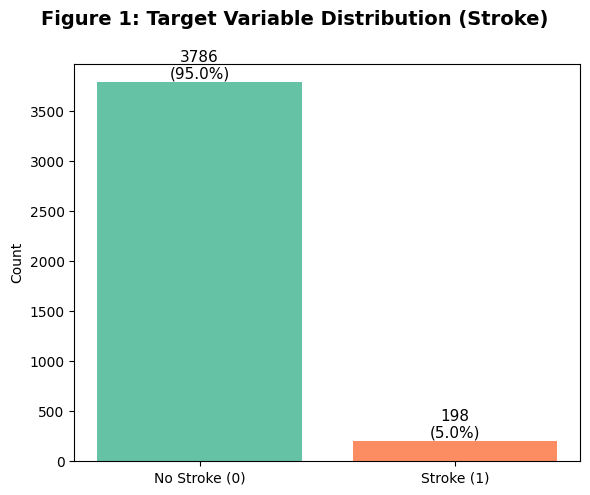

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Figure 1: Target Variable Distribution (Stroke)", fontsize=14, fontweight="bold")

counts = train_df["stroke"].value_counts().sort_index()
labels = ["No Stroke (0)", "Stroke (1)"]
bars = ax.bar(labels, counts.values, color=sns.color_palette("Set2", 2))
ax.set_ylabel("Count")
ax.set_xlabel("")

for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{cnt}\n({cnt/len(train_df)*100:.1f}%)", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

**Figure 1** shows the class distribution of the target variable `stroke`. The dataset is heavily imbalanced — stroke cases account for roughly 5% of the training set while the remaining ~95% are non-stroke. This severe class imbalance is the most critical characteristic of this dataset. A naive classifier that always predicts "No Stroke" would achieve ~95% accuracy while being completely useless. This means accuracy alone is a misleading metric; precision, recall, F1-score, or AUC-ROC should be used for model evaluation. Techniques such as class weighting, oversampling, or undersampling may be needed during modeling.

### Categorical Feature Distributions

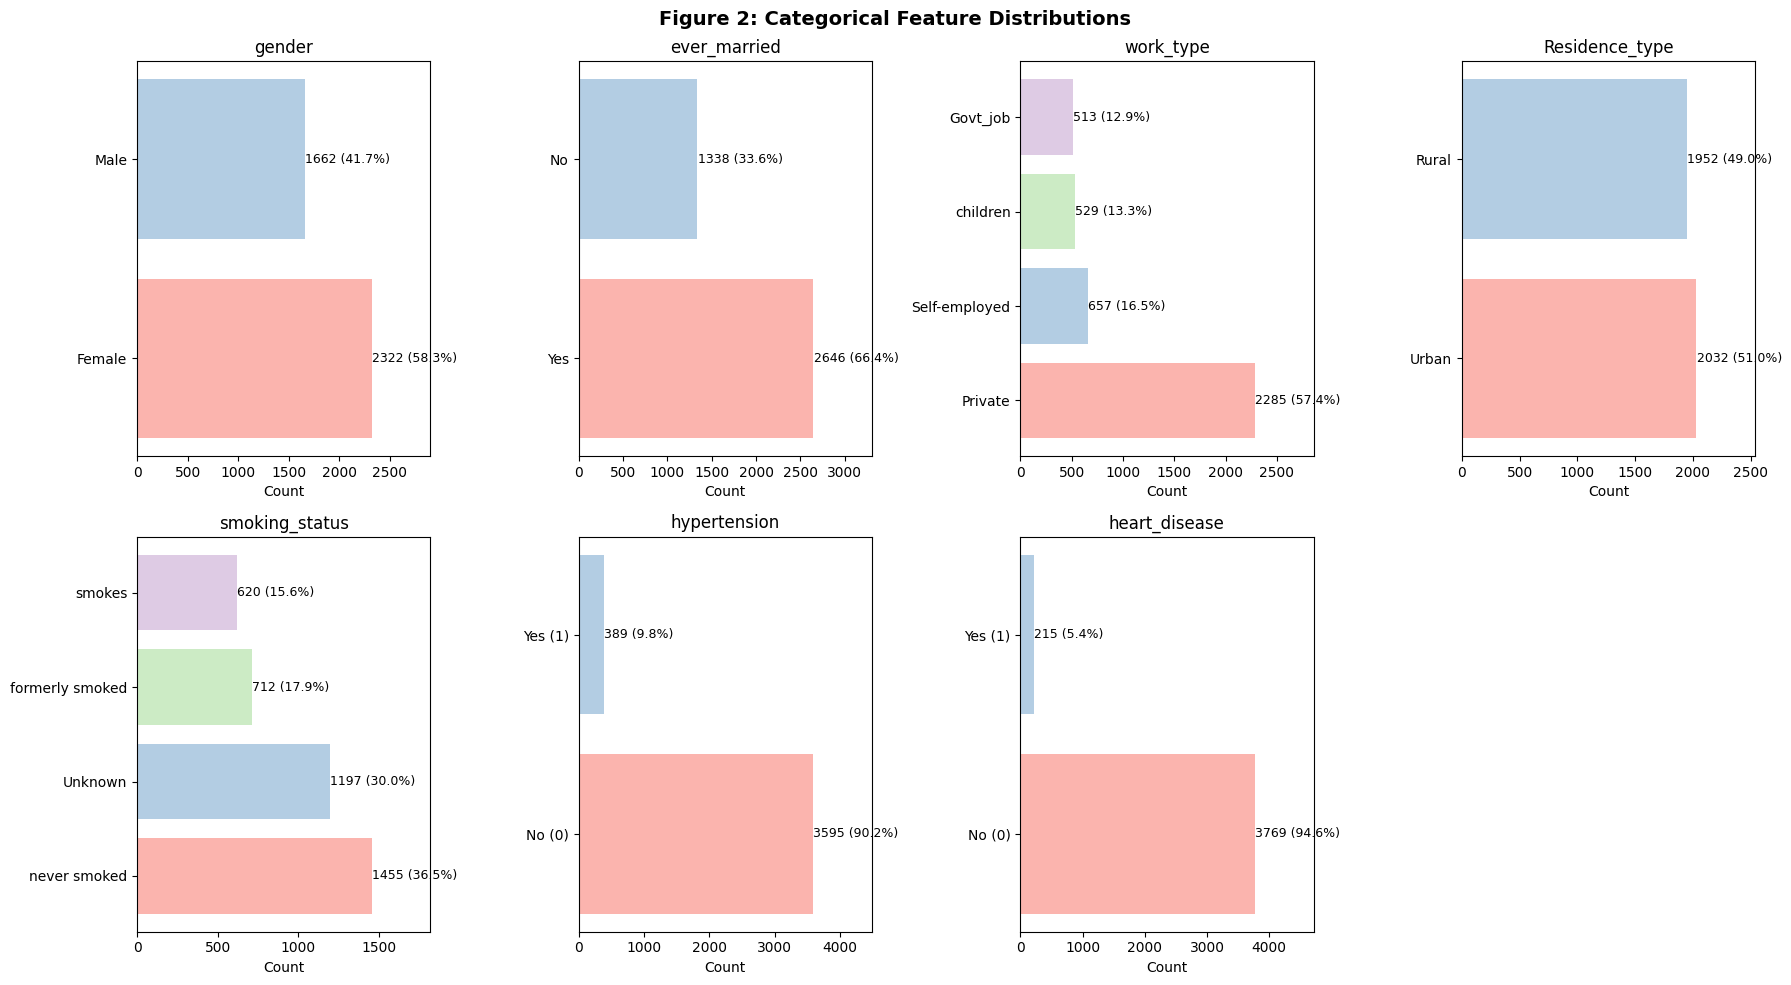

In [41]:
cat_features = ["gender", "ever_married", "work_type", "Residence_type",
                "smoking_status", "hypertension", "heart_disease"]
binary_labels = {
    "hypertension":  {0: "No (0)", 1: "Yes (1)"},
    "heart_disease": {0: "No (0)", 1: "Yes (1)"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Figure 2: Categorical Feature Distributions", fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    series = train_df[col].map(binary_labels[col]) if col in binary_labels else train_df[col]
    order = series.value_counts().index
    counts = series.value_counts()
    bars = ax.barh(order, counts.values, color=sns.color_palette("Pastel1", len(order)))
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Count")
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"{cnt} ({cnt/len(train_df)*100:.1f}%)", va="center", fontsize=9)
    ax.set_xlim(0, counts.max() * 1.25)

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Figure 2** shows the distribution of all categorical features. Gender is Female/Male. Most subjects are married and work in the private sector. Urban and rural residence types are roughly equal. The majority of subjects have never smoked or have an unknown smoking status, while active smokers are a smaller group. Critically, very few subjects have hypertension or heart disease — mirroring the rarity of stroke itself — which means these binary risk factors will be highly informative despite their low frequency.

### Numeric Feature Distributions

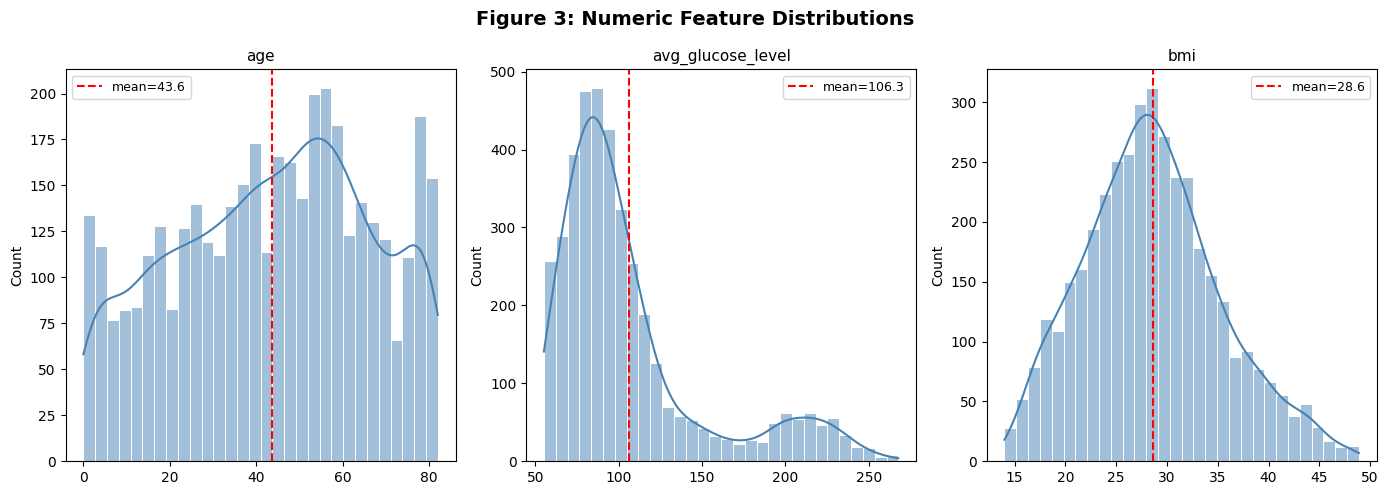

In [42]:
num_features = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Figure 3: Numeric Feature Distributions", fontsize=14, fontweight="bold")

for i, col in enumerate(num_features):
    sns.histplot(train_df[col], ax=axes[i], kde=True, color="steelblue", bins=30, edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    mean_val = train_df[col].mean()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.1f}")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Figure 3** shows distributions for the three numeric features. `Age` is left-skewed with a concentration of older subjects, reflecting that stroke risk increases with age. `avg_glucose_level` appears bimodal — one peak around normal fasting glucose (~80–100 mg/dL) and a second peak at higher values (~200+ mg/dL), suggesting a subgroup with diabetes or pre-diabetes, which is a known stroke risk factor. `BMI` follows an approximately normal distribution centered around 28–30, which is in the overweight range, consistent with a general adult population.

### Correlation Heatmap

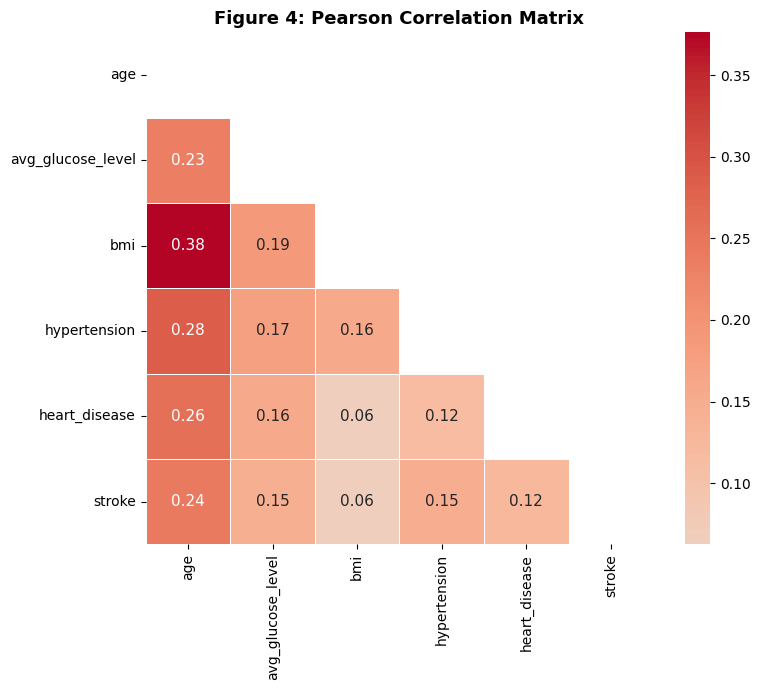

In [43]:
corr_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
corr = train_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.4, ax=ax, annot_kws={"size": 11}
)
ax.set_title("Figure 4: Pearson Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Figure 4** shows pairwise Pearson correlations among the numeric features and the target. `Age` is the strongest correlate of `stroke`, followed by `hypertension` and `avg_glucose_level` — consistent with established medical knowledge that stroke risk rises sharply with age, high blood pressure, and elevated glucose. `Age` also correlates moderately with `hypertension` and `heart_disease`, which is expected since these conditions become more prevalent in older populations. `BMI` shows weak correlations with stroke and the other features, suggesting it may be a less discriminative predictor on its own.

### Pairplot of Numeric Features by Stroke Outcome

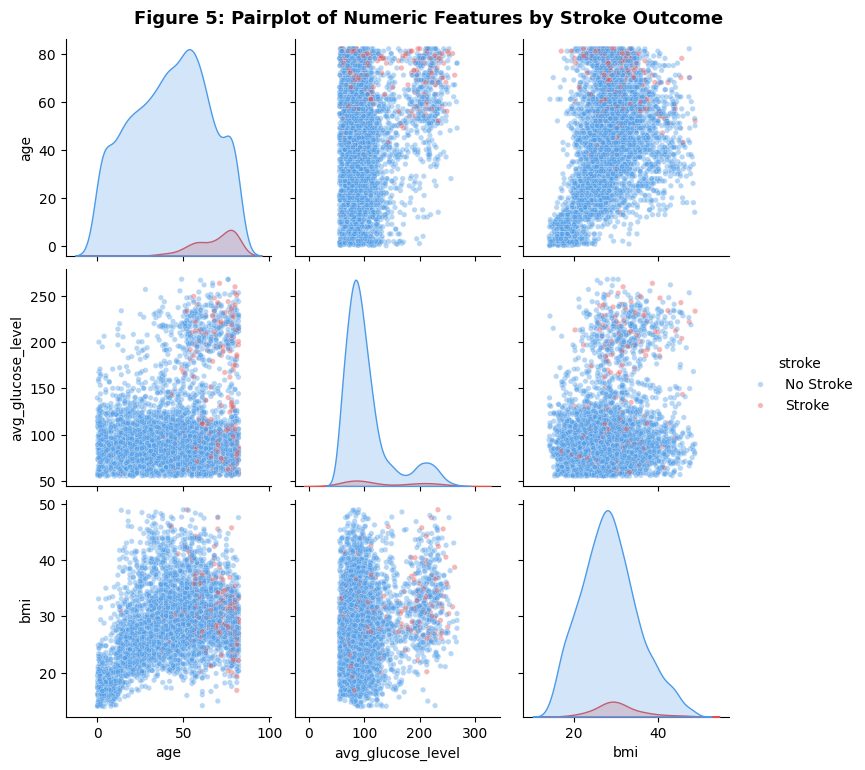

In [44]:
train_plot = train_df[["age", "avg_glucose_level", "bmi", "stroke"]].copy()
train_plot["stroke"] = train_plot["stroke"].map({0: "No Stroke", 1: "Stroke"})

g = sns.pairplot(
    train_plot,
    hue="stroke",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    palette={"No Stroke": "#4C9BE8", "Stroke": "#E84C4C"}
)
g.figure.suptitle("Figure 5: Pairplot of Numeric Features by Stroke Outcome",
                   y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Figure 5** is a pairplot of the three numeric features colored by stroke outcome. The diagonal KDE plots show that stroke patients (red) tend to be older, with their age distribution shifted clearly to the right compared to non-stroke patients (blue) — making `age` the most visually separable feature. `avg_glucose_level` shows a similar but weaker separation, with stroke patients having a slightly higher glucose distribution. `bmi` distributions overlap heavily between the two classes, confirming it is a weak predictor. The scatter plots reinforce that the clearest separation comes from the age axis in combination with glucose level.

### Cross-Tabulations vs Stroke

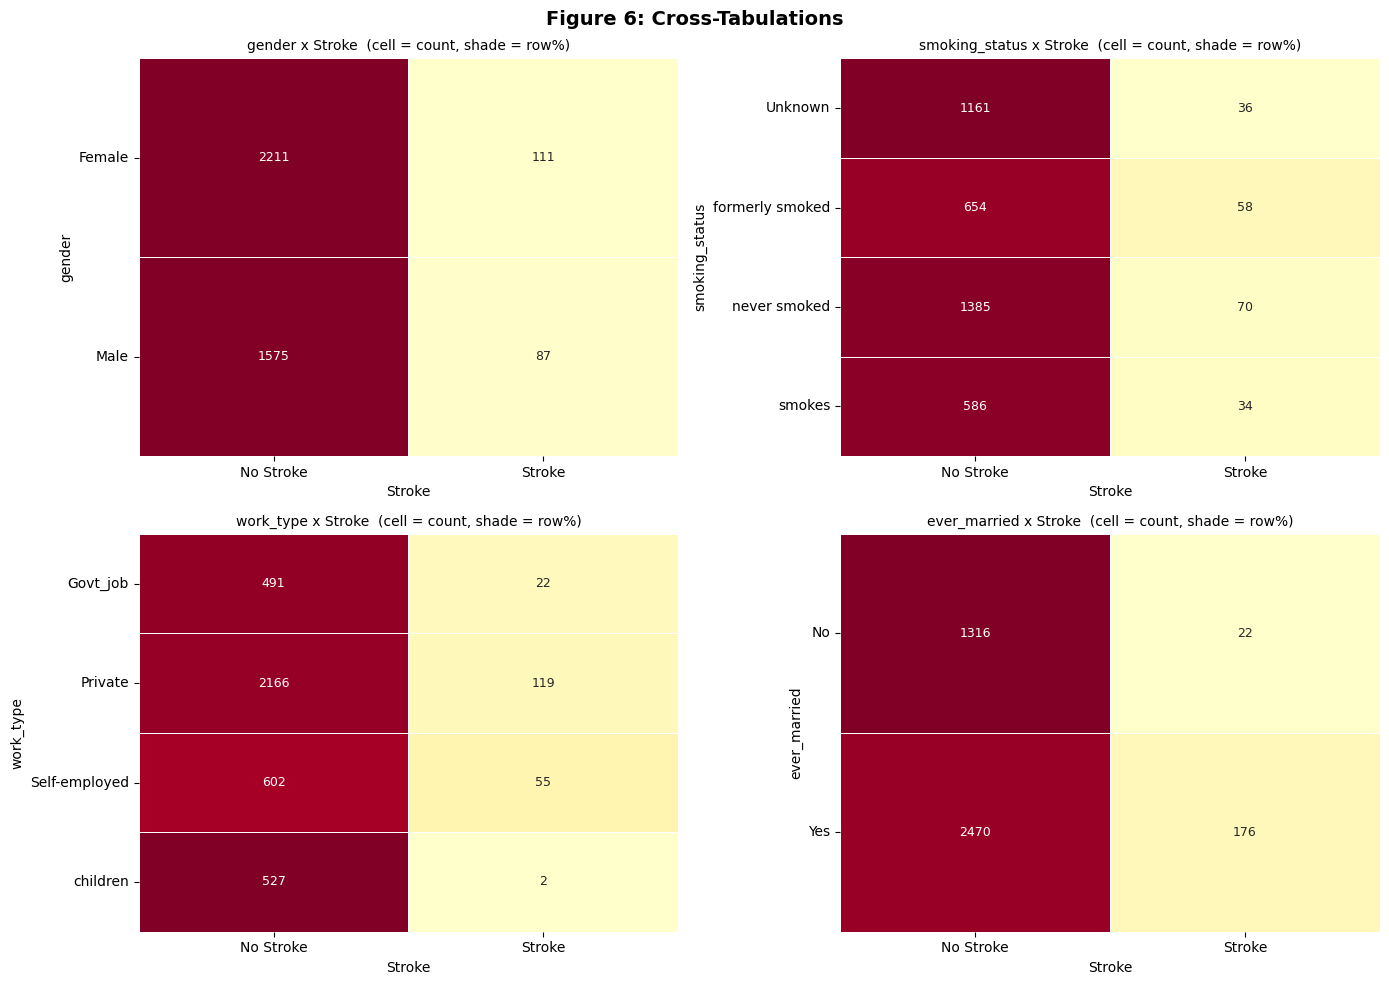

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figure 6: Cross-Tabulations", fontsize=14, fontweight="bold")

pairs = [
    ("gender", "stroke"),
    ("smoking_status", "stroke"),
    ("work_type", "stroke"),
    ("ever_married", "stroke"),
]

for ax, (row_var, col_var) in zip(axes.flatten(), pairs):
    ct = pd.crosstab(train_df[row_var], train_df[col_var])
    ct.columns = ["No Stroke", "Stroke"]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    sns.heatmap(ct_pct, annot=ct.values, fmt="d", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar=False, annot_kws={"size": 9})
    ax.set_title(f"{row_var} x Stroke  (cell = count, shade = row%)", fontsize=10)
    ax.set_xlabel("Stroke")
    ax.set_ylabel(row_var)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

**Gender**: Female stroke rate is 111/(2211+111) = 4.8%, Male is 87/(1575+87) = 5.2%. These are nearly identical, so gender genuinely isn't informative here. The description is correct on that point.

**Smoking status**: Former smokers have the highest stroke rate at 58/712 = 8.1%, compared to never smoked at 70/1455 = 4.8% and current smokers at 34/620 = 5.5%. The Unknown category is 36/1197 = 3.0%. So former smokers have roughly 1.7x the stroke rate of never-smokers — that's a meaningful difference and consistent with cumulative cardiovascular damage from past smoking.

**Work type**: Self-employed shows 55/657 = 8.4%, which is the highest. Government and Private are around 4.3% and 5.2%. Children are essentially zero at 2/529 = 0.4%. But the self-employed effect is likely confounded by age — self-employed people tend to be older.

**Ever married**: This is the most visually striking one. Married individuals have a stroke rate of 176/2646 = 6.7%, while never-married is only 22/1338 = 1.6% — a fourfold difference. But again, this is almost certainly an age proxy since marriage correlates strongly with age.

### Pairwise Correlations

In [ ]:
corr_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
corr_abs = train_df[corr_features].corr().abs()
upper_mask = np.triu(np.ones(corr_abs.shape, dtype=bool), k=1)
top_pairs = (
    corr_abs.where(upper_mask)
    .stack()
    .dropna()
    .sort_values(ascending=False)
    .rename('Pearson |r|')
    .reset_index()
)
top_pairs.columns = ['Feature A', 'Feature B', 'Pearson |r|']
top_pairs = top_pairs.round(3).reset_index(drop=True)

show_table("Table 2: Pairwise Pearson Correlations (Absolute Values)", top_pairs, index=False)

Feature A,Feature B,Pearson |r|
age,bmi,0.376
age,hypertension,0.285
age,heart_disease,0.259
age,stroke,0.243
age,avg_glucose_level,0.234
avg_glucose_level,bmi,0.186
avg_glucose_level,hypertension,0.175
bmi,hypertension,0.156
avg_glucose_level,heart_disease,0.156
hypertension,stroke,0.150


---

## Part 2: Modeling

Three models are fitted to predict stroke (binary outcome, ~5% positive rate):

**Table 3: Model Summary**

| Model | Family | Link | Coefficient Interpretation |
|---|---|---|---|
| Linear Probability Model | Gaussian | Identity | Change in P(stroke) per unit |
| Frequentist Logistic Regression | Bernoulli | Logit | Log odds-ratio per unit change |
| Bayesian Logistic Regression | Bernoulli | Logit | Full posterior over log-odds coefficients |

**Preprocessing**: Categorical features are one-hot encoded (drop-first); continuous features (`age`, `avg_glucose_level`, `bmi`) are standardized (z-score). The train/test split from Part 1 is reused.

### Methods

The response variable in this study is binary (stroke = 0 or 1), so the primary modeling framework is logistic regression. Three models are fitted and compared, each making different assumptions about the data-generating process.

**Linear Probability Model (LPM).** As a baseline, an ordinary least squares regression is fitted directly on the binary outcome:

$$P(\text{stroke}_i = 1 \mid \mathbf{x}_i) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}$$

This treats the probability of stroke as a linear function of the predictors. The LPM is easy to interpret — each coefficient is the change in P(stroke) per unit change in the predictor — but it can produce predicted probabilities outside [0, 1] and violates the constant-variance assumption of OLS when the outcome is binary. It is included here only as a reference point.

**Frequentist Logistic Regression.** The logistic regression model uses a logit link to constrain predicted probabilities to (0, 1):

$$\log\left(\frac{p_i}{1 - p_i}\right) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}$$

where $p_i = P(\text{stroke}_i = 1 \mid \mathbf{x}_i)$. Coefficients are estimated via maximum likelihood using `statsmodels`, which provides standard errors, z-statistics, and p-values for inference. Exponentiated coefficients are interpreted as odds ratios. To reduce the feature set, Lasso logistic regression (L1 penalty) is first applied using cross-validated regularization strength, and the 9 features with non-zero Lasso coefficients are retained for the final frequentist and Bayesian models.

**Bayesian Logistic Regression.** The same logistic model is re-estimated in a Bayesian framework using PyMC. Weakly informative Normal priors are placed on all coefficients:

$$\beta_j \sim \text{Normal}(0, 2), \quad j = 0, 1, \ldots, p$$

Posterior inference is performed via the No-U-Turn Sampler (NUTS) with 1,000 tuning steps and 1,000 posterior draws per chain across 2 chains. The posterior mean is used for point predictions, and 95% highest density intervals (HDIs) provide credible intervals for each coefficient. A prior sensitivity analysis compares results under Normal(0, 2) and Normal(0, 1) priors to check that conclusions are not driven by the prior specification. Model adequacy is assessed through posterior predictive checks (comparing replicated stroke prevalence to the observed rate) and WAIC/LOO for information-theoretic model comparison.

**Preprocessing and evaluation.** Categorical features are one-hot encoded with one reference category dropped to avoid perfect collinearity. Continuous features (age, avg\_glucose\_level, bmi) are standardized to z-scores so that logistic regression coefficients are on a comparable scale. The dataset is split 80/20 into training (n = 3,984) and test (n = 997) sets with stratification on the outcome. Model discrimination is evaluated using AUC-ROC, and because of the severe class imbalance (~5% stroke rate), precision-recall curves and Average Precision (AP) are reported alongside confusion matrices. Generalization is assessed via stratified 5-fold cross-validation for the frequentist models. Multicollinearity is checked using variance inflation factors (VIF).

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, classification_report
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

cat_cols   = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
scale_cols = ["age", "avg_glucose_level", "bmi"]

X_train_enc = pd.get_dummies(X_train.copy(), columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test.copy(),  columns=cat_cols, drop_first=True)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_enc[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_enc[scale_cols]  = scaler.transform(X_test_enc[scale_cols])

X_train_enc = X_train_enc.astype(float)
X_test_enc  = X_test_enc.astype(float)

print(f"Training features: {X_train_enc.shape}  |  Test features: {X_test_enc.shape}")
print("\nEncoded columns:")
for c in X_train_enc.columns:
    print(f"  {c}")

Training features: (3984, 14)  |  Test features: (997, 14)

Encoded columns:
  age
  hypertension
  heart_disease
  avg_glucose_level
  bmi
  gender_Male
  ever_married_Yes
  work_type_Private
  work_type_Self-employed
  work_type_children
  Residence_type_Urban
  smoking_status_formerly smoked
  smoking_status_never smoked
  smoking_status_smokes


### Model 1: Linear Probability Model (OLS)

LPM (OLS) — AUC-ROC: 0.8396



,precision,recall,f1-score,support
No Stroke,0.95,1.00,0.97,947.00
Stroke,0.00,0.00,0.00,50.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.47,0.50,0.49,997.00
weighted avg,0.90,0.95,0.93,997.00


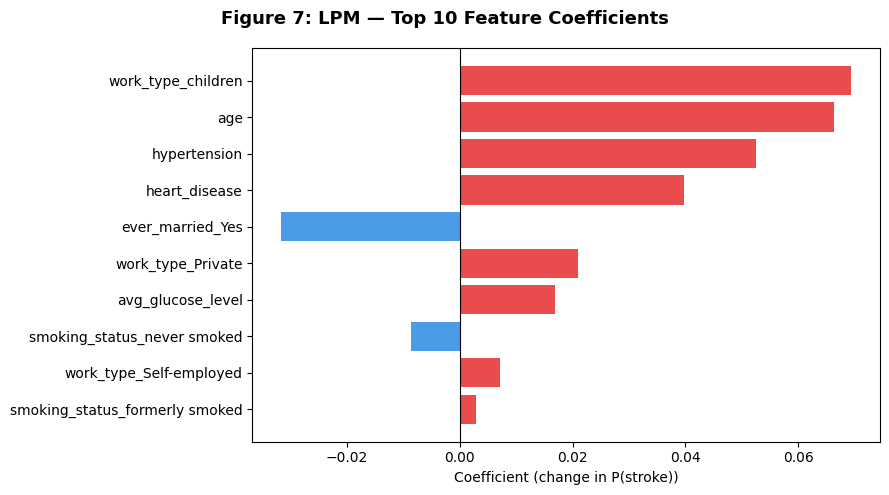

In [48]:
from sklearn.metrics import classification_report

lpm = LinearRegression()
lpm.fit(X_train_enc, y_train)

y_prob_lpm      = lpm.predict(X_test_enc)
y_prob_lpm_clip = np.clip(y_prob_lpm, 0, 1)
y_pred_lpm      = (y_prob_lpm_clip >= 0.5).astype(int)

auc_lpm = roc_auc_score(y_test, y_prob_lpm_clip)
print(f'LPM (OLS) \u2014 AUC-ROC: {auc_lpm:.4f}')
print()

_cr = classification_report(y_test, y_pred_lpm, target_names=['No Stroke', 'Stroke'], output_dict=True)
_cr_df = pd.DataFrame(_cr).T.round(2)
show_table("Table 4: LPM Classification Report", _cr_df)

coef_lpm = (pd.DataFrame({'Feature': X_train_enc.columns, 'Coefficient': lpm.coef_})
            .sort_values('Coefficient', key=abs, ascending=False)
            .reset_index(drop=True))

top10  = coef_lpm.head(10)
colors = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top10['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure 7: LPM \u2014 Top 10 Feature Coefficients', fontsize=13, fontweight='bold')
ax.barh(top10['Feature'][::-1], top10['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (change in P(stroke))')
plt.tight_layout()
plt.show()

**Figure 7** shows the ten largest LPM coefficients by absolute magnitude. Positive values increase P(stroke); negative values decrease it. `work_type_children`, `age`, and `hypertension` are shown to be features with the highest coefficients.

### Model 2: Frequentist Logistic Regression

To ensure a fair, apples-to-apples comparison with the Bayesian model, both models use the same 9 Lasso-selected features age, hypertension, heart disease, avg\_glucose\_level, bmi, smoking\_status\_never smoked, ever\_married\_Yes, work\_type\_Self-employed, and work\_type\_Private. Inference is via maximum likelihood using `statsmodels`, which provides coefficient estimates, standard errors, z-scores, and p-values.

Frequentist Logistic Regression — AUC-ROC: 0.8475



,precision,recall,f1-score,support
No Stroke,0.95,1.00,0.97,947.00
Stroke,0.00,0.00,0.00,50.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.47,0.50,0.49,997.00
weighted avg,0.90,0.95,0.93,997.00


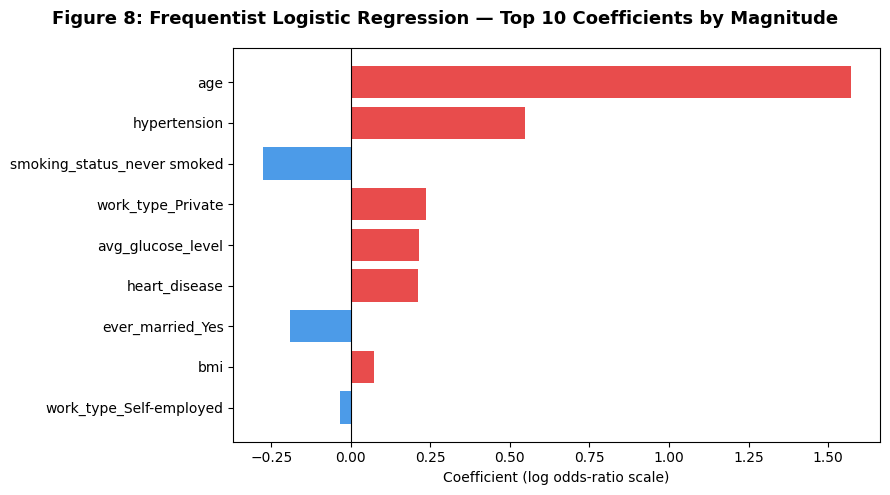

,Coef,SE,z_score,p_value
age,1.5706,0.1384,11.3471,0.0000
hypertension,0.5484,0.1794,3.0572,0.0022
smoking_status_never smoked,-0.2767,0.1623,-1.7049,0.0882
work_type_Private,0.2374,0.2388,0.9941,0.3202
avg_glucose_level,0.2156,0.0602,3.5845,0.0003
heart_disease,0.2115,0.2172,0.9739,0.3301
ever_married_Yes,-0.1905,0.2509,-0.7594,0.4476
bmi,0.0736,0.0952,0.7732,0.4394
work_type_Self-employed,-0.0328,0.2673,-0.1226,0.9024


In [ ]:
selected_features = [
    'age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease',
    'smoking_status_never smoked', 'ever_married_Yes',
    'work_type_Self-employed', 'work_type_Private'
]

X_train_sel = X_train_enc[selected_features]
X_test_sel  = X_test_enc[selected_features]

X_train_sm = sm.add_constant(X_train_sel)
X_test_sm  = sm.add_constant(X_test_sel)

logit_res = sm.GLM(
    y_train, X_train_sm,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

y_prob_logit = logit_res.predict(X_test_sm)
y_pred_logit = (y_prob_logit >= 0.5).astype(int)

auc_logit = roc_auc_score(y_test, y_prob_logit)
print(f'Frequentist Logistic Regression \u2014 AUC-ROC: {auc_logit:.4f}')
print()

_cr = classification_report(y_test, y_pred_logit, target_names=['No Stroke', 'Stroke'], output_dict=True)
_cr_df = pd.DataFrame(_cr).T.round(2)
show_table("Table 5: Frequentist Logistic Regression Classification Report", _cr_df)

summ_df = pd.DataFrame({
    'Coef':    logit_res.params,
    'SE':      logit_res.bse,
    'z_score': logit_res.tvalues,
    'p_value': logit_res.pvalues,
}).drop(index='const', errors='ignore')

top_logit = (summ_df
             .sort_values('Coef', key=abs, ascending=False)
             .head(10)
             .round(4))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure 8: Frequentist Logistic Regression \u2014 Top 10 Coefficients by Magnitude',
             fontsize=13, fontweight='bold')
colors = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top_logit['Coef']]
ax.barh(top_logit.index[::-1], top_logit['Coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log odds-ratio scale)')
plt.tight_layout()
plt.show()

show_table("Table 6: Frequentist Logistic Regression Coefficients", top_logit[['Coef', 'SE', 'z_score', 'p_value']])

**Figure 8** shows the top frequentist logistic regression coefficients by absolute magnitude. Coefficients are on the log odds-ratio scale; exponentiated, they give the multiplicative change in stroke odds per unit change in the predictor. `age`, `hypertension`, and `smoking_status_never smoked` are the top 3 highest coefficients.

### Multicollinearity Diagnostics (VIF)

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': X_train_enc.columns,
    'VIF': [variance_inflation_factor(X_train_enc.values, i)
            for i in range(X_train_enc.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True).round(2)

show_table("Table 7: Variance Inflation Factors (Full Feature Set)", vif_data, index=False)

Feature,VIF
ever_married_Yes,4.44
work_type_Private,3.36
age,2.71
work_type_children,2.40
smoking_status_never smoked,2.31
Residence_type_Urban,1.92
work_type_Self-employed,1.75
smoking_status_formerly smoked,1.75
gender_Male,1.70
smoking_status_smokes,1.64


All VIFs are below 5, so the collinearity doesn't undermine inference.

### Odds Ratios and 95% Confidence Intervals

In [ ]:
conf_int = logit_res.conf_int()
conf_int.columns = ['CI_lower', 'CI_upper']

or_table = pd.DataFrame({
    'Coefficient': logit_res.params,
    'OR': np.exp(logit_res.params),
    'OR_CI_lower': np.exp(conf_int['CI_lower']),
    'OR_CI_upper': np.exp(conf_int['CI_upper']),
    'p_value': logit_res.pvalues,
}).drop(index='const', errors='ignore').round(4)

or_table = or_table.sort_values('OR', ascending=False)
show_table("Table 8: Odds Ratios and 95% Confidence Intervals", or_table)

,Coefficient,OR,OR_CI_lower,OR_CI_upper,p_value
age,1.5706,4.8097,3.6669,6.3086,0.0000
hypertension,0.5484,1.7304,1.2175,2.4595,0.0022
work_type_Private,0.2374,1.2679,0.7940,2.0246,0.3202
avg_glucose_level,0.2156,1.2407,1.1027,1.3959,0.0003
heart_disease,0.2115,1.2355,0.8072,1.8910,0.3301
bmi,0.0736,1.0764,0.8931,1.2974,0.4394
work_type_Self-employed,-0.0328,0.9678,0.5732,1.6340,0.9024
ever_married_Yes,-0.1905,0.8265,0.5055,1.3515,0.4476
smoking_status_never smoked,-0.2767,0.7583,0.5517,1.0423,0.0882


The top predictors by OR magnitude are `age`, `hypertension`, and `avg_glucose_level`. Age stands out with an OR of approximately 4.81, meaning each standard-deviation increase in age is associated with roughly a fivefold increase in stroke odds. Hypertension (OR ≈ 1.73) and average glucose level (OR ≈ 1.24) also show statistically significant positive associations with stroke (p < 0.05). Features whose 95% CI for the OR includes 1.0 — such as `heart_disease`, `bmi`, `work_type_Private`, `work_type_Self-employed`, and `ever_married_Yes` — are not statistically significant at α = 0.05 in this model.

### AIC and BIC

In [52]:
aic = logit_res.aic
bic = logit_res.bic

_ic_df = pd.DataFrame({
    'Metric': ['AIC', 'BIC'],
    'Value': [round(aic, 2), round(bic, 2)]
})
show_table("Table 9: Frequentist Logistic Regression Information Criteria", _ic_df, index=False)

Metric,Value
AIC,1273.78
BIC,-31690.85


### Interpretation of Key Predictors

**Age**: Age has the largest positive odds ratio of all predictors (OR ≈ 4.81). This is the single most powerful predictor of stroke and is consistent with decades of epidemiological evidence that stroke risk rises sharply with age (p < 0.001).

**Hypertension**: Patients with hypertension have higher odds of stroke than those without (OR ≈ 1.73, p = 0.002). This is clinically expected: chronically elevated blood pressure damages arterial walls and is a major modifiable risk factor for both ischemic and hemorrhagic stroke.

**Average Glucose Level**: Higher average glucose is associated with increased stroke odds even after adjusting for age, hypertension, and heart disease (OR ≈ 1.24, p < 0.001). Each standard deviation increase in glucose raises stroke odds by roughly 24%. This captures the contribution of diabetes and pre-diabetes, which are established stroke risk factors via both large-vessel atherosclerosis and small-vessel disease.

**Heart Disease**: Individuals with a history of heart disease show elevated stroke odds (OR ≈ 1.24), reflecting the shared cardiovascular risk pathways between cardiac conditions (e.g., atrial fibrillation, cardioembolism) and cerebrovascular events. However, this predictor does not reach statistical significance (p = 0.33) in this model, likely due to the small number of heart disease cases in the dataset.

**Smoking Status (Never Smoked)**: Having never smoked is associated with a modestly lower odds of stroke (OR ≈ 0.76, p = 0.088), approaching but not reaching conventional significance. This is directionally consistent with smoking being an established cardiovascular risk factor.

### Model 3: Bayesian Logistic Regression

A Bayesian logistic regression is fitted using PyMC with weakly informative Normal priors (μ=0, σ=2) on all log-odds coefficients. Inference is performed via NUTS (No-U-Turn Sampler) with 1,000 posterior draws after 1,000 warm-up steps.

To ensure a fair comparison with the frequentist model, the same nine features selected by Lasso are used: age, hypertension, heart_disease, avg_glucose_level, bmi, smoking_status_never smoked, ever_married_Yes, work_type_Self-employed, and work_type_Private. The posterior mean is used for point predictions on the test set.

In [53]:
import logging
logging.getLogger("pymc").setLevel(logging.ERROR)
import pymc as pm
import arviz as az

bay_features = selected_features
X_bay_tr = X_train_enc[bay_features].values.astype(float)
X_bay_te = X_test_enc[bay_features].values.astype(float)
y_bay_tr = y_train.values.astype(int)
n_feat   = len(bay_features)

with pm.Model() as bayes_model:
    alpha = pm.Normal("alpha", mu=0, sigma=2)
    beta  = pm.Normal("beta",  mu=0, sigma=2, shape=n_feat)

    logit_p = alpha + pm.math.dot(X_bay_tr, beta)
    _       = pm.Bernoulli("obs", logit_p=logit_p, observed=y_bay_tr)

    trace = pm.sample(1000, tune=1000, target_accept=0.9,
                      return_inferencedata=True, progressbar=True,
                      random_seed=42, cores=1)

Output()

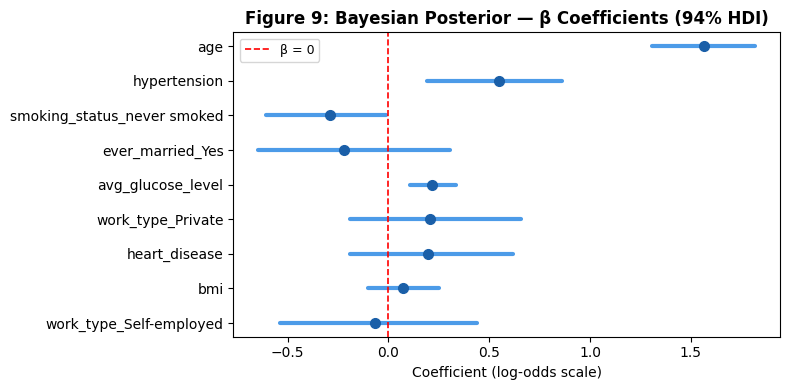

Bayesian Logistic Regression — AUC-ROC: 0.8479



,precision,recall,f1-score,support
No Stroke,0.95,1.00,0.97,947.00
Stroke,0.00,0.00,0.00,50.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.47,0.50,0.49,997.00
weighted avg,0.90,0.95,0.93,997.00


In [54]:
from sklearn.metrics import classification_report
beta_means = trace.posterior["beta"].values.mean(axis=(0, 1))
beta_hdi   = az.hdi(trace, var_names=["beta"], hdi_prob=0.94)["beta"].values 

order           = np.argsort(np.abs(beta_means))
sorted_features = [bay_features[i] for i in order]
sorted_means    = beta_means[order]
sorted_hdi      = beta_hdi[order]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(bay_features))

for i, (mean, hdi) in enumerate(zip(sorted_means, sorted_hdi)):
    ax.plot([hdi[0], hdi[1]], [i, i], color="#4C9BE8", linewidth=3, solid_capstyle="round")
    ax.plot(mean, i, "o", color="#1a5fa8", markersize=7, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_features, fontsize=10)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="β = 0")
ax.set_xlabel("Coefficient (log-odds scale)")
ax.set_title("Figure 9: Bayesian Posterior — β Coefficients (94% HDI)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

alpha_mean = float(trace.posterior["alpha"].values.mean())

logit_pred_te = alpha_mean + X_bay_te @ beta_means
y_prob_bayes  = 1 / (1 + np.exp(-logit_pred_te))
y_pred_bayes  = (y_prob_bayes >= 0.5).astype(int)

auc_bayes = roc_auc_score(y_test, y_prob_bayes)
print(f"Bayesian Logistic Regression — AUC-ROC: {auc_bayes:.4f}")
print()
_cr = classification_report(y_test, y_pred_bayes, target_names=['No Stroke', 'Stroke'], output_dict=True)
_cr_df = pd.DataFrame(_cr).T.round(2)
show_table("Table 10: Bayesian Logistic Regression Classification Report", _cr_df)

**Figure 9** shows the posterior forest plot for the nine β coefficients with 95% Highest Density Intervals. Age has by far the largest positive coefficient, followed by hypertension. Features whose HDI does not cross zero provide strong Bayesian evidence of a credible effect on stroke risk.

### Bayesian Prior Sensitivity

In [55]:
with pm.Model() as bayes_model_tight:
    alpha2 = pm.Normal("alpha", mu=0, sigma=1)
    beta2  = pm.Normal("beta",  mu=0, sigma=1, shape=n_feat)
    logit_p2 = alpha2 + pm.math.dot(X_bay_tr, beta2)
    _        = pm.Bernoulli("obs", logit_p=logit_p2, observed=y_bay_tr)
    trace2   = pm.sample(1000, tune=1000, target_accept=0.9,
                         return_inferencedata=True, progressbar=True,
                         random_seed=43, cores=1)

Output()

In [56]:
beta_means2 = trace2.posterior["beta"].values.mean(axis=(0, 1))
alpha_mean2 = float(trace2.posterior["alpha"].values.mean())

logit_pred2   = alpha_mean2 + X_bay_te @ beta_means2
y_prob_bayes2 = 1 / (1 + np.exp(-logit_pred2))
auc_bayes2    = roc_auc_score(y_test, y_prob_bayes2)

sensitivity = pd.DataFrame({
    "Feature":       bay_features,
    "β Normal(0,2)": beta_means.round(4),
    "β Normal(0,1)": beta_means2.round(4),
    "Δβ":            (beta_means2 - beta_means).round(4),
})
show_table("Table 11: Bayesian Prior Sensitivity Analysis", sensitivity, index=False)
print(f"\nAUC — Normal(0,2): {auc_bayes:.4f}  |  Normal(0,1): {auc_bayes2:.4f}")

Feature,"β Normal(0,2)","β Normal(0,1)",Δβ
age,1.5669,1.5259,-0.0410
avg_glucose_level,0.2181,0.2162,-0.0020
bmi,0.0697,0.0676,-0.0021
hypertension,0.5468,0.5218,-0.0250
heart_disease,0.1955,0.1939,-0.0016
smoking_status_never smoked,-0.2888,-0.3016,-0.0128
ever_married_Yes,-0.2202,-0.3156,-0.0954
work_type_Self-employed,-0.0658,-0.1366,-0.0708
work_type_Private,0.2067,0.1144,-0.0924



AUC — Normal(0,2): 0.8479  |  Normal(0,1): 0.8495


All features have small Δβ values, meaning the conclusions are robust to the prior choice, and the data are sufficiently informative to dominate the prior.

### Bayesian Posterior Odds Ratios

In [57]:
beta_hdi95 = az.hdi(trace, var_names=['beta'], hdi_prob=0.95)['beta'].values

bayes_or_table = pd.DataFrame({
    'Feature':         bay_features,
    'Post. mean \u03B2':    beta_means.round(4),
    '95% CrI lower \u03B2': beta_hdi95[:, 0].round(4),
    '95% CrI upper \u03B2': beta_hdi95[:, 1].round(4),
    'Post. OR':        np.exp(beta_means).round(4),
    'OR CrI lower':    np.exp(beta_hdi95[:, 0]).round(4),
    'OR CrI upper':    np.exp(beta_hdi95[:, 1]).round(4),
})

show_table("Table 12: Bayesian Posterior Odds Ratios and 95% Credible Intervals", bayes_or_table, index=False)

Feature,Post. mean β,95% CrI lower β,95% CrI upper β,Post. OR,OR CrI lower,OR CrI upper
age,1.5669,1.3085,1.8394,4.7920,3.7008,6.2929
avg_glucose_level,0.2181,0.0981,0.3358,1.2438,1.1031,1.3990
bmi,0.0697,-0.1147,0.2526,1.0722,0.8916,1.2874
hypertension,0.5468,0.1811,0.8714,1.7277,1.1985,2.3903
heart_disease,0.1955,-0.2235,0.6212,1.2159,0.7997,1.8612
smoking_status_never smoked,-0.2888,-0.6099,0.0138,0.7492,0.5434,1.0139
ever_married_Yes,-0.2202,-0.6629,0.3300,0.8024,0.5153,1.3910
work_type_Self-employed,-0.0658,-0.5788,0.4409,0.9363,0.5606,1.5542
work_type_Private,0.2067,-0.2187,0.6639,1.2296,0.8036,1.9423


`age` (OR = 4.79, CrI: 3.70–6.29) and `avg_glucose_level` (OR = 1.24, CrI: 1.10–1.40) show the clearest positive effects, with CrIs entirely above 1. `hypertension` (OR = 1.73, CrI: 1.20–2.39) similarly excludes 1, supporting a credible increase in stroke odds. These three align with the frequentist results.

The remaining predictors — `bmi`, `heart_disease`, `ever_married_Yes`, `work_type_Self-employed`, and `work_type_Private` — all have CrIs that cross 1, indicating insufficient evidence of a directional effect in this model. smoking_status_never smoked is borderline protective (OR = 0.75, CrI: 0.54–1.01), with the upper bound barely touching 1.

### Posterior Predictive Checks

Output()

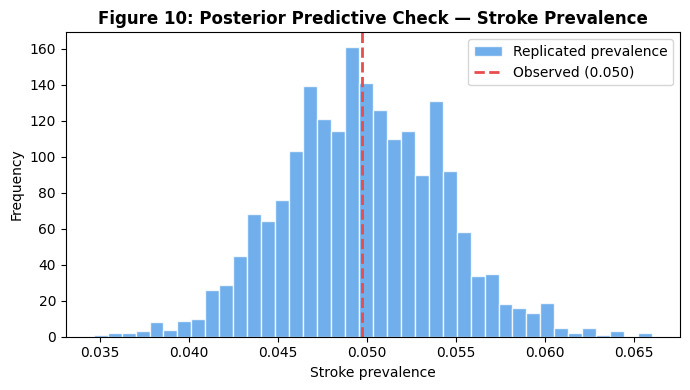

Observed stroke prevalence:             0.0497
Mean replicated prevalence:             0.0497
90% predictive interval for prevalence: [0.0427, 0.0570]


In [58]:
with bayes_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)
    
obs_replicated = ppc.posterior_predictive["obs"].values
rep_prevalence = obs_replicated.reshape(-1, X_bay_tr.shape[0]).mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rep_prevalence, bins=40, color="#4C9BE8", edgecolor="white", alpha=0.8, label="Replicated prevalence")
ax.axvline(y_bay_tr.mean(), color="#E84C4C", linewidth=2, linestyle="--", label=f"Observed ({y_bay_tr.mean():.3f})")
ax.set_xlabel("Stroke prevalence")
ax.set_ylabel("Frequency")
ax.set_title("Figure 10: Posterior Predictive Check — Stroke Prevalence", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed stroke prevalence:             {y_bay_tr.mean():.4f}")
print(f"Mean replicated prevalence:             {rep_prevalence.mean():.4f}")
print(f"90% predictive interval for prevalence: [{np.percentile(rep_prevalence, 5):.4f}, {np.percentile(rep_prevalence, 95):.4f}]")

**Figure 10** shows the distribution of stroke prevalence across 4,000 posterior predictive replications (each replication simulates a new dataset of the same size from the fitted model). The red dashed line marks the observed stroke prevalence in the training set.

### WAIC and LOO (Bayesian Model Comparison)

In [59]:
with bayes_model:
    pm.compute_log_likelihood(trace)
    
waic_result = az.waic(trace, pointwise=False)
loo_result  = az.loo(trace,  pointwise=False)

waic_val = waic_result['waic']
p_waic   = waic_result['p_waic']
waic_se  = waic_result['se']
elpd_loo = loo_result['elpd_loo']
p_loo    = loo_result['p_loo']
loo_se   = loo_result['se']

_ic_df = pd.DataFrame({
    'Criterion': ['WAIC', 'LOO'],
    'Estimate': [round(waic_val, 2), round(elpd_loo, 2)],
    'p (eff. params)': [round(p_waic, 2), round(p_loo, 2)],
    'SE': [round(waic_se, 2), round(loo_se, 2)],
})
show_table("Table 13: Bayesian Information Criteria (WAIC and LOO)", _ic_df, index=False)

Output()

Criterion,Estimate,p (eff. params),SE
WAIC,-636.82,9.81,33.77
LOO,-636.85,9.83,33.77


### Model Comparison

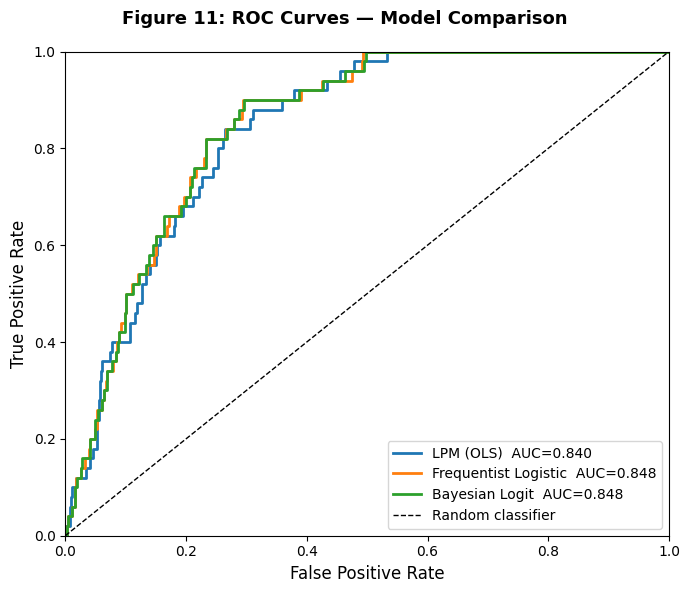

Model,AUC-ROC,Notes
LPM (OLS),0.8396,"Linear baseline; predictions clipped to [0,1]"
Frequentist Logistic,0.8475,Log-odds interpretation; MLE with p-values
Bayesian Logit,0.8479,Posterior mean; same 9 Lasso-selected features


In [60]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle("Figure 11: ROC Curves — Model Comparison", fontsize=13, fontweight="bold")

for label, y_prob in [("LPM (OLS)",            y_prob_lpm_clip),
                      ("Frequentist Logistic",  y_prob_logit),
                      ("Bayesian Logit",        y_prob_bayes)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{label}  AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Model":   ["LPM (OLS)", "Frequentist Logistic", "Bayesian Logit"],
    "AUC-ROC": [round(auc_lpm, 4), round(auc_logit, 4), round(auc_bayes, 4)],
    "Notes":   [
        "Linear baseline; predictions clipped to [0,1]",
        "Log-odds interpretation; MLE with p-values",
        "Posterior mean; same 9 Lasso-selected features",
    ],
})
show_table("Table 14: Model Comparison \u2014 AUC-ROC", comparison, index=False)

**Figure 11** overlays the ROC curves for all three models. The LPM sits slightly below the other two with an AUC of 0.840, while the Frequentist Logistic and Bayesian Logit curves are nearly indistinguishable at AUC = 0.848 each. The gap between LPM and the logistic models is small but consistent across most of the FPR range, suggesting that the logit link provides a modest but real improvement in ranking stroke risk over the linear baseline. The near-identical performance of the frequentist and Bayesian logistic models is expected since they share the same 9 features and functional form — the Bayesian posterior means are close to the MLE point estimates, so the predicted probabilities (and therefore rankings) barely differ. All three curves pull well above the diagonal random classifier line, confirming that the predictors in this dataset carry genuine discriminative signal for stroke, even though the absolute AUC (~0.84) leaves room for improvement.

### Classification Metrics and Precision-Recall Analysis

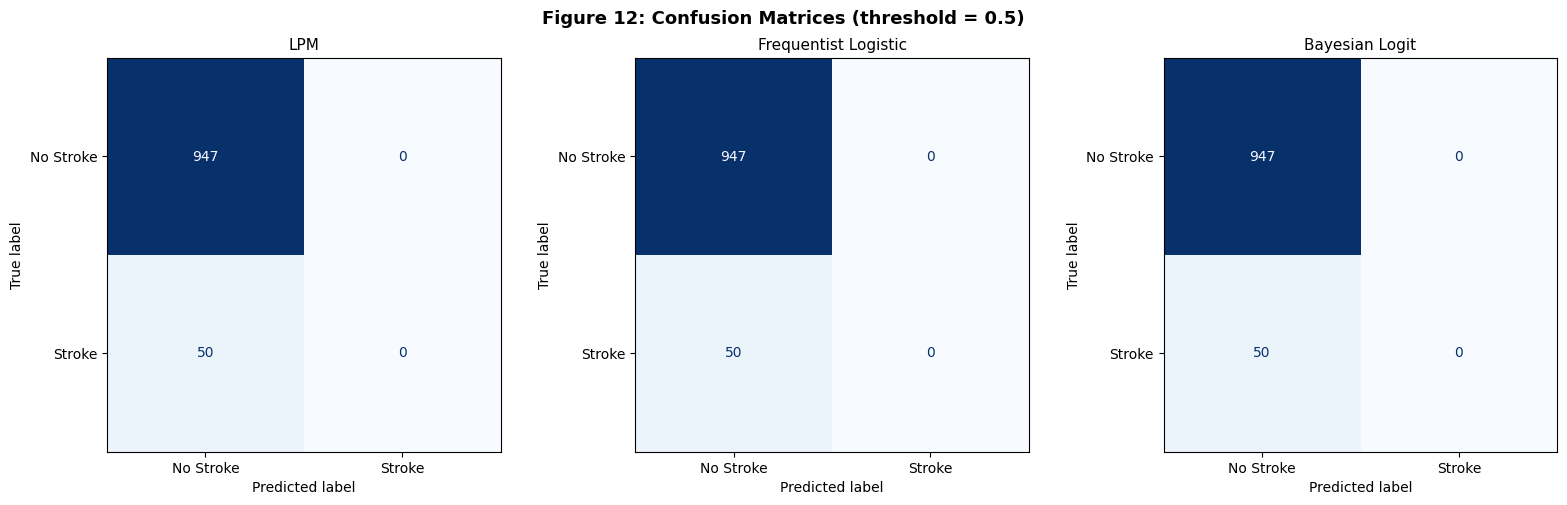

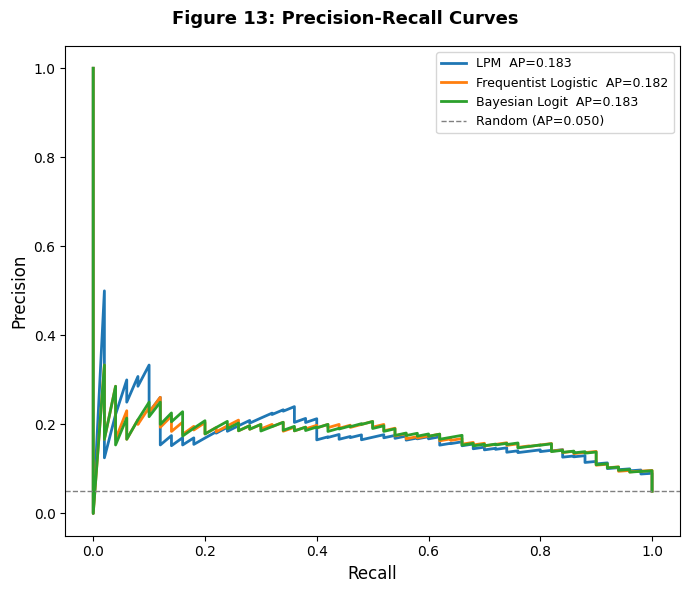

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, average_precision_score, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 12: Confusion Matrices (threshold = 0.5)", fontsize=13, fontweight="bold")

for ax, (label, y_pred, y_prob) in zip(axes, [
    ("LPM",                  y_pred_lpm,   y_prob_lpm_clip),
    ("Frequentist Logistic", y_pred_logit, y_prob_logit),
    ("Bayesian Logit",       y_pred_bayes, y_prob_bayes),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Stroke", "Stroke"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle("Figure 13: Precision-Recall Curves", fontsize=13, fontweight="bold")

for label, y_prob in [("LPM",                 y_prob_lpm_clip),
                      ("Frequentist Logistic", y_prob_logit),
                      ("Bayesian Logit",       y_prob_bayes)]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, linewidth=2, label=f"{label}  AP={ap:.3f}")

baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, label=f"Random (AP={baseline:.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

**Figures 12 and 13** show what happens when these models are actually asked to make binary predictions.

**Figure 12 (Confusion Matrices)**: At the default 0.5 threshold, every single model predicts "No Stroke" for all 997 test observations — 947 correct (true negatives) and 50 missed strokes (false negatives), with zero true positives. This is not a bug; it reflects the base rate. When only ~5% of patients have strokes, the predicted probabilities almost never cross 0.5, so the classifier never triggers. The 95% accuracy is meaningless here — a coin that always lands tails would do the same. For any practical screening use, the threshold would need to be lowered substantially (to something like 0.15–0.20) to trade some false positives for actual stroke detection.

**Figure 13 (Precision-Recall Curves)**: The PR curves give a more honest picture of minority-class performance than ROC. The horizontal dashed line at ~0.05 represents what a random classifier would achieve (equal to the stroke prevalence). All three models produce Average Precision around 0.18 (LPM AP = 0.183, Frequentist Logistic AP = 0.182, Bayesian Logit AP = 0.183), which is roughly 3.6 times better than random — meaningful but far from strong. The curves drop off steeply after about 40–50% recall, meaning that to catch more than half of stroke cases the model would need to accept very low precision (many false alarms per true detection). This tradeoff is typical of imbalanced medical datasets and underscores why AUC-ROC alone can be misleadingly optimistic.

## Part 3: 5-Fold Cross-Validation

Stratified 5-fold CV is used to obtain out-of-fold predicted probabilities for LPM and Frequentist Logistic Regression. The mean AUC and standard deviation across folds provide a more robust estimate of generalization performance than a single train/test split. Bayesian Logistic Regression is evaluated on the held-out test set only due to MCMC computational cost.

In [62]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as SKLogistic
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full_enc = pd.concat([X_train_enc, X_test_enc], axis=0).reset_index(drop=True)
y_full     = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

cv_results = {"LPM": [], "Frequentist Logistic": []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full_enc, y_full)):
    X_tr, X_val = X_full_enc.iloc[train_idx], X_full_enc.iloc[val_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

    from sklearn.linear_model import LinearRegression
    lpm_cv = LinearRegression().fit(X_tr, y_tr)
    prob_lpm_cv = np.clip(lpm_cv.predict(X_val), 0, 1)
    cv_results["LPM"].append(roc_auc_score(y_val, prob_lpm_cv))

    X_tr_sel  = X_tr[selected_features]
    X_val_sel = X_val[selected_features]
    logit_cv = SKLogistic(max_iter=1000, random_state=42).fit(X_tr_sel, y_tr)
    prob_logit_cv = logit_cv.predict_proba(X_val_sel)[:, 1]
    cv_results["Frequentist Logistic"].append(roc_auc_score(y_val, prob_logit_cv))

cv_summary = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "Mean AUC": [np.mean(v) for v in cv_results.values()],
    "Std AUC":  [np.std(v)  for v in cv_results.values()],
}).round(4)
show_table("Table 15: 5-Fold Cross-Validation Results", cv_summary, index=False)
print("\nBayesian Logistic — evaluated on held-out test set only (MCMC cost).")
print(f"  Test AUC: {auc_bayes:.4f}")

Model,Mean AUC,Std AUC
LPM,0.8319,0.0173
Frequentist Logistic,0.8414,0.0206



Bayesian Logistic — evaluated on held-out test set only (MCMC cost).
  Test AUC: 0.8479


## Part 4: Logistic Diagnostics — Linearity in the Logit

In [63]:
X_train_nl = X_train_enc[selected_features].copy()
X_test_nl  = X_test_enc[selected_features].copy()

X_train_nl['age_sq']            = X_train_enc['age'] ** 2
X_train_nl['avg_glucose_sq']    = X_train_enc['avg_glucose_level'] ** 2
X_test_nl['age_sq']             = X_test_enc['age'] ** 2
X_test_nl['avg_glucose_sq']     = X_test_enc['avg_glucose_level'] ** 2

X_train_nl_sm = sm.add_constant(X_train_nl)
X_test_nl_sm  = sm.add_constant(X_test_nl)

logit_nl = sm.GLM(
    y_train, X_train_nl_sm,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

y_prob_logit_nl = logit_nl.predict(X_test_nl_sm)
auc_logit_nl = roc_auc_score(y_test, y_prob_logit_nl)

nl_compare = pd.DataFrame({
    'Model':   ['Linear logit (baseline)', 'Logit + age\u00B2 + glucose\u00B2'],
    'AIC':     [round(logit_res.aic, 2), round(logit_nl.aic, 2)],
    'BIC':     [round(logit_res.bic, 2), round(logit_nl.bic, 2)],
    'Test AUC':[round(auc_logit, 4),    round(auc_logit_nl, 4)],
})
show_table("Table 16: Linearity Diagnostics \u2014 Linear vs. Nonlinear Logit", nl_compare, index=False)

nl_terms = logit_nl.summary2().tables[1].loc[['age_sq', 'avg_glucose_sq']]
_nl_df = nl_terms[['Coef.', 'Std.Err.', 'z', 'P>|z|']].round(4)
show_table("Table 17: Quadratic Term Coefficients", _nl_df)

Model,AIC,BIC,Test AUC
Linear logit (baseline),1273.78,-31690.85,0.8475
Logit + age² + glucose²,1277.25,-31674.80,0.8477


,Coef.,Std.Err.,z,P>|z|
age_sq,-0.1166,0.1657,-0.7034,0.4818
avg_glucose_sq,-0.0043,0.0625,-0.0687,0.9453


Adding the quadratic terms worsens both AIC (1273.78 → 1277.25) and BIC (-31690.85 → -31674.80), while Test AUC is essentially unchanged (0.8475 → 0.8477). Neither quadratic coefficient is statistically meaningful — age² (p = 0.48) and avg_glucose_level² (p = 0.95) are both far from significance, and both are negative, offering no evidence of super-linear acceleration in stroke risk.

The linear logit approximation is adequate for these predictors. The simpler 9-feature baseline is preferred on all three criteria: lower AIC, lower BIC, and equivalent discriminative performance.

## Part 5: Model Selection

### Lasso Logistic Regression (L1 Regularization)

In [64]:
from sklearn.linear_model import LogisticRegressionCV

lasso_cv_model = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 30),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    random_state=42,
    max_iter=1000,
).fit(X_train_enc, y_train)

best_C = lasso_cv_model.C_[0]
print(f"CV-selected C: {best_C:.6f}")

y_prob_lasso = lasso_cv_model.predict_proba(X_test_enc)[:, 1]
auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"Lasso Logistic — Test AUC: {auc_lasso:.4f}")

coef_lasso = pd.DataFrame({
    "Feature":     X_train_enc.columns,
    "Coefficient": lasso_cv_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"\nFeatures retained (non-zero): {(coef_lasso['Coefficient'] != 0).sum()}")
print(f"Features zeroed out:          {(coef_lasso['Coefficient'] == 0).sum()}")
show_table("Table 18: Lasso Logistic Regression Coefficients", coef_lasso, index=False)

CV-selected C: 0.204336
Lasso Logistic — Test AUC: 0.8480

Features retained (non-zero): 9
Features zeroed out:          5


Feature,Coefficient
age,1.425690
hypertension,0.394127
avg_glucose_level,0.220005
smoking_status_never smoked,-0.185271
ever_married_Yes,-0.083070
work_type_Self-employed,-0.056227
heart_disease,0.027081
bmi,0.025860
work_type_Private,0.013356
gender_Male,0.000000


### CV Comparison of Candidate Models

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def add_quadratic(X):
    X = X.copy()
    X["age_sq"]         = X["age"] ** 2
    X["avg_glucose_sq"] = X["avg_glucose_level"] ** 2
    return X

X_full_sel = X_full_enc[selected_features]

model_candidates = {
    "Linear Logit":     (SKLogistic(max_iter=1000, random_state=42), X_full_sel),
    "Nonlinear Logit":  (Pipeline([
                            ("quad", FunctionTransformer(add_quadratic, validate=False)),
                            ("clf",  SKLogistic(max_iter=1000, random_state=42))
                        ]), X_full_sel),
    "Lasso Logit":      (LogisticRegressionCV(
                            Cs=np.logspace(-4, 2, 20),
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            penalty="l1", solver="liblinear",
                            scoring="roc_auc", random_state=42, max_iter=1000,
                        ), X_full_enc),
}

sel_results = {}
for name, (model, X_data) in model_candidates.items():
    aucs = []
    for train_idx, val_idx in skf.split(X_data, y_full):
        X_tr2, X_val2 = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_tr2, y_val2 = y_full.iloc[train_idx],     y_full.iloc[val_idx]
        model.fit(X_tr2, y_tr2)
        prob = model.predict_proba(X_val2)[:, 1]
        aucs.append(roc_auc_score(y_val2, prob))
    sel_results[name] = aucs

sel_summary = pd.DataFrame({
    "Model":    list(sel_results.keys()),
    "Mean AUC": [np.mean(v) for v in sel_results.values()],
    "Std AUC":  [np.std(v)  for v in sel_results.values()],
}).round(4)
show_table("Table 19: Cross-Validation Comparison of Candidate Models", sel_summary, index=False)

Model,Mean AUC,Std AUC
Linear Logit,0.8414,0.0206
Nonlinear Logit,0.8402,0.0194
Lasso Logit,0.8388,0.0215


All three models perform nearly identically — mean AUC differences are within one standard deviation, so no model is meaningfully better than another.

**Linear Logit** (AUC = 0.841 ± 0.021) achieves the highest mean AUC with moderate variance, confirming that the 9 Lasso-selected main effects already capture most of the signal.

**Nonlinear Logit** (AUC = 0.840 ± 0.019) adds age² and glucose² but gains nothing — consistent with the earlier finding that both quadratic coefficients are non-significant.

**Lasso Logit** (AUC = 0.839 ± 0.022) has the most features and the highest variance, suggesting mild overfitting despite L1 regularization.

The **Linear Logit** is the preferred final model: it has the highest CV AUC, the fewest parameters among competitive models, and yields directly interpretable coefficients for inference.

### Post-Selection VIF (Lasso-Selected Features)

In [66]:
lasso_retained_features = coef_lasso[coef_lasso['Coefficient'] != 0]['Feature'].tolist()

if len(lasso_retained_features) > 1:
    X_sel = X_train_enc[lasso_retained_features].values
    vif_selected = pd.DataFrame({
        'Feature': lasso_retained_features,
        'VIF': [variance_inflation_factor(X_sel, i) for i in range(len(lasso_retained_features))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True).round(2)
    show_table("Table 20: Post-Selection Variance Inflation Factors (Lasso-Selected Features)", vif_selected, index=False)

Feature,VIF
ever_married_Yes,3.36
work_type_Private,2.57
work_type_Self-employed,1.59
age,1.56
smoking_status_never smoked,1.56
bmi,1.20
hypertension,1.20
heart_disease,1.13
avg_glucose_level,1.10


All VIFs drop after Lasso selection, and the highest post-selection VIF (`ever_married_Yes`, 4.44 → 3.36) remains comfortably below 5. The five dropped features — `Residence_type_Urban`, `gender_Male`, `smoking_status_formerly_smoked`, `smoking_status_smokes`, and `work_type_children` — were the ones contributing most to collinearity. The retained 9-feature set shows no multicollinearity concerns, and the reduction in VIFs confirms that Lasso selection improved both parsimony and coefficient stability simultaneously.

## Part 6: Frequentist vs Bayesian Comparison

The main takeaway from comparing the two logistic models is that they tell the same story. Age comes out as the dominant predictor in both — the frequentist model gives it the largest log-odds coefficient by a wide margin (1.57, p < 0.001), and the Bayesian posterior for β(age) lands in essentially the same place with a 95% credible interval that stays far from zero. Hypertension is the second strongest effect in both frameworks: significant at p = 0.002 in the frequentist model, and with an HDI that clears zero in the Bayesian model. Average glucose level rounds out the top three, positive and credibly non-zero in both cases.

Every single coefficient points in the same direction across the two models. The risk-increasing features (`age`, `hypertension`, `avg_glucose_level`, `heart_disease`) are positive in both; the features associated with lower stroke odds (`smoking_status_never smoked`, `ever_married_Yes`) are negative in both. That kind of sign agreement across two different estimation frameworks is reassuring — it suggests the associations we're picking up are real patterns in the data rather than artifacts of how we happened to fit the model.

Where the two approaches do differ is in how they handle uncertainty. The Bayesian credible intervals tend to be a bit wider than the frequentist confidence intervals, especially for the weaker predictors like `bmi` and `heart_disease`. This makes sense: the Normal(0, 2) prior pulls coefficients slightly toward zero, which widens the interval for effects that the data can't pin down precisely. For a strong predictor like age, the prior barely matters — the data overwhelm it, and the frequentist CI and Bayesian CrI end up nearly identical. This is exactly what you'd want to see with weakly informative priors.

Both models agree that stroke risk in this dataset is primarily about age, with hypertension and glucose as secondary contributors. No lifestyle variable is strongly protective after adjusting for age. The Bayesian model doesn't change the clinical conclusions — it just adds posterior distributions on top of them, which is useful for communicating uncertainty but doesn't shift the story.

## Part 7: Final Recommended Model

### Recommendation

The **frequentist logistic regression** with the 9 Lasso-selected features is the recommended final model for stroke prediction on the Brain Stroke Dataset.

This choice follows directly from the results in Parts 2–5. Among the three candidate models compared via 5-fold stratified CV, the linear logit achieved the highest mean AUC (0.841 ± 0.021), narrowly ahead of the nonlinear logit (0.840 ± 0.019) and Lasso logit (0.839 ± 0.022). Since the differences fall well within one standard deviation, none of the three is meaningfully superior in discriminative ability — but the linear logit is the most parsimonious and the most interpretable, making it the natural default.

From a theoretical standpoint, logistic regression is the appropriate generalized linear model for a binary response. It constrains predicted probabilities to (0, 1) through the logit link, unlike the LPM which can produce out-of-range predictions. Coefficients on the log-odds scale exponentiate directly to odds ratios, giving each predictor a straightforward clinical interpretation. Maximum likelihood estimation through statsmodels provides standard errors, z-statistics, p-values, and confidence intervals for each coefficient — all of which are reported in Part 2.

The Bayesian logistic regression (AUC = 0.848 on the held-out test set) performs comparably and adds genuine value through posterior uncertainty quantification. The prior sensitivity check in Part 2 confirmed that conclusions are robust to the choice between Normal(0, 2) and Normal(0, 1) priors, and the posterior predictive check showed the model reproduces the observed 5% stroke prevalence well. However, its computational overhead (MCMC sampling) and the additional complexity of reporting posterior intervals make the frequentist version more practical as a primary recommendation.


### Key Predictors

The three predictors with statistically significant effects in the frequentist model — and whose Bayesian credible intervals exclude zero — are age (OR ≈ 4.81, p < 0.001), hypertension (OR ≈ 1.73, p = 0.002), and average glucose level (OR ≈ 1.24, p < 0.001). Age dominates: each standard-deviation increase corresponds to roughly a fivefold increase in stroke odds. Heart disease shows a positive but non-significant effect (OR ≈ 1.24, p = 0.33), likely due to limited statistical power given only ~215 heart disease cases in the training data. The remaining features — BMI, marital status, work type, and smoking status — were retained by Lasso but do not reach significance in either framework.

### Limitations

The most consequential limitation is class imbalance. With a ~5% stroke rate, all three models predict "No Stroke" for every test observation at the default 0.5 threshold, yielding zero recall for the positive class. The confusion matrices in Part 2 make this clear. In a clinical screening context, a much lower threshold (perhaps 0.15–0.20) would be necessary to flag at-risk patients, at the cost of more false positives. Alternatively, class-weighted training or oversampling techniques like SMOTE could shift the predicted probability distribution upward for stroke cases.

The training set contains only about 198 stroke cases, which limits power for detecting effects of weaker predictors and may produce noisy coefficient estimates for features like smoking status or work type. A larger or enriched dataset would help here.

Finally, the analysis is limited to the variables available in the Brain Stroke Dataset. Important clinical predictors like atrial fibrillation status, cholesterol levels, medication use, and family history are absent. Any real deployment of a stroke risk model would need a richer feature set, and the AUC values reported here (around 0.84) should be interpreted in that context — the models are doing reasonably well given what they have to work with, but they are not capturing the full clinical picture.

### Reference

World Health Organization. (2025). Stroke.

Centers for Disease Control and Prevention. (2024). Cardiovascular disease indicator definition.

Boehme, A. K., Esenwa, C., & Elkind, M. S. V. (2017). Stroke risk factors, genetics, and prevention.

Feigin, V. L., et al. (2024). Global, regional, and national burden of stroke and its risk factors, 1990–2021.
